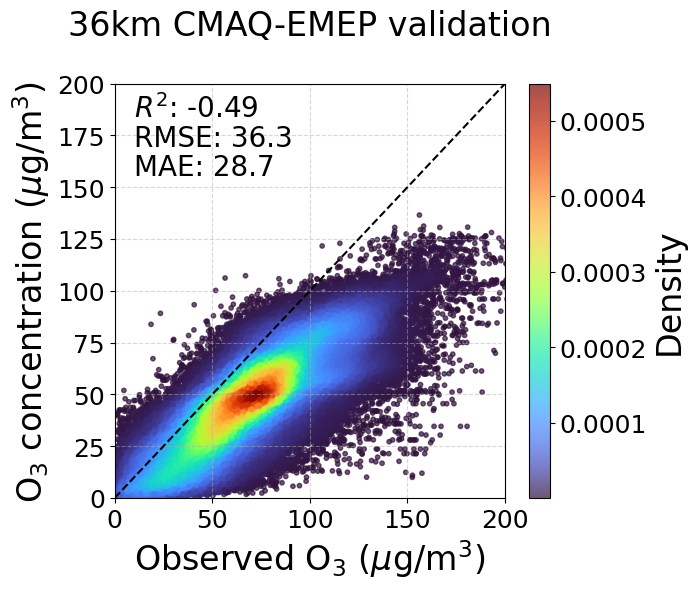

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load site-matched data
df = pd.read_csv('/home/qinjialing/validation_emis/2018_emep/output/site_grid_matching_2019.csv')

obs = df['obs_MDA8'].values
emep = df['emep_MDA8'].values

mask_emep = ~np.isnan(obs) & ~np.isnan(emep)
obs_emep = obs[mask_emep]
emep_val = emep[mask_emep]

r2_emep = r2_score(obs_emep, emep_val)
rmse_emep = np.sqrt(mean_squared_error(obs_emep, emep_val))
mae_emep = mean_absolute_error(obs_emep, emep_val)


TEXT_SIZE = 24
METRIC_SIZE = 20
TICK_SIZE = 18

fig, ax1 = plt.subplots(figsize=(7, 6))

# Left panel: 36km CMAQ-EMEP validation
xy1 = np.vstack([obs_emep, emep_val])
z1 = gaussian_kde(xy1)(xy1)
scatter1 = ax1.scatter(obs_emep, emep_val, c=z1, s=10, cmap='turbo', alpha=0.7)
ax1.set_title("36km CMAQ-EMEP validation", fontsize=TEXT_SIZE, pad=35)
ax1.plot([0, 200], [0, 200], color="black", linestyle='--')
ax1.set_xlim(0, 200)
ax1.set_ylim(0, 200)
ax1.set_xlabel(r'Observed $\mathrm{O}_{3}$ ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
ax1.set_ylabel(r'O$_{3}$ concentration ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
ax1.text(0.05, 0.92, "$R^2$: {r2:.2f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
ax1.text(0.05, 0.85, "RMSE: {rmse:.1f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
ax1.text(0.05, 0.78, "MAE: {mae:.1f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
cbar1 = fig.colorbar(scatter1, ax=ax1)
cbar1.set_label('Density', fontsize=TEXT_SIZE)
cbar1.ax.tick_params(labelsize=TICK_SIZE)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.tick_params(axis='both', labelsize=TICK_SIZE)

plt.tight_layout()
plt.show()


CMAQ (reference): R2=-0.5875, RMSE=38.2959, MAE=30.0069


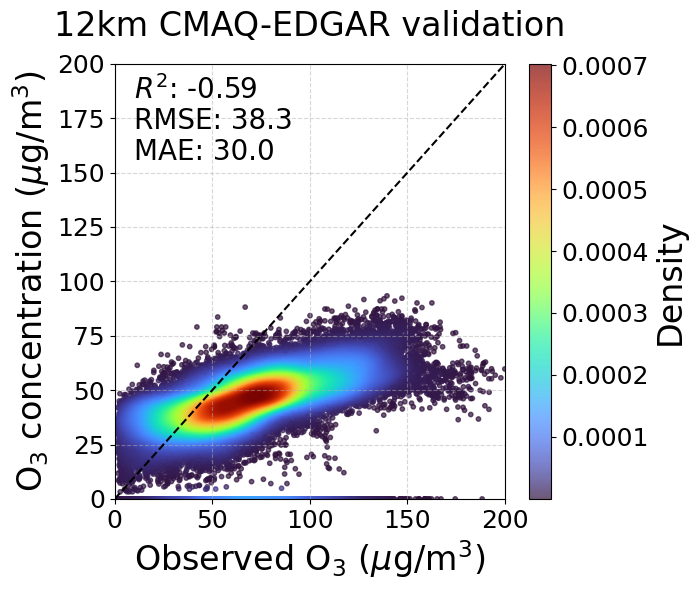

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Left panel uses the reference matched data, kept identical to the source plot
REFERENCE_MATCHED_FILE = '/home/qinjialing/trae_code/appendix/12km_matched_data.csv'

VAL_TEXT_SIZE = 24
VAL_METRIC_SIZE = 20
VAL_TICK_SIZE = 18


def draw_scatter_axis(ax, obs, y, title):
    """Draw a single validation scatter axis."""
    r2 = r2_score(obs, y)
    rmse = np.sqrt(mean_squared_error(obs, y))
    mae = mean_absolute_error(obs, y)

    # KDE (subsample fitting for large data to speed up)
    xy = np.vstack([obs, y])
    n = len(obs)
    rng = np.random.default_rng(42)
    if n > 30000:
        idx_fit = rng.choice(n, 30000, replace=False)
        kde = gaussian_kde(xy[:, idx_fit])
    else:
        kde = gaussian_kde(xy)
    z = kde(xy)
    order = z.argsort()
    obs_s = obs[order]
    y_s = y[order]
    z_s = z[order]

    scatter = ax.scatter(obs_s, y_s, c=z_s, s=10, cmap='turbo', alpha=0.7)
    ax.set_title(title, fontsize=VAL_TEXT_SIZE, pad=20)
    ax.plot([0, 200], [0, 200], color="black", linestyle='--')
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_xlabel(r'Observed $\mathrm{O}_{3}$ ($\mu$g/m$^3$)', fontsize=VAL_TEXT_SIZE)
    ax.set_ylabel(r'$\mathrm{O}_{3}$ concentration ($\mu$g/m$^3$)', fontsize=VAL_TEXT_SIZE)
    ax.text(0.05, 0.92, f"$R^2$: {r2:.2f}", transform=ax.transAxes, fontsize=VAL_METRIC_SIZE)
    ax.text(0.05, 0.85, f"RMSE: {rmse:.1f}", transform=ax.transAxes, fontsize=VAL_METRIC_SIZE)
    ax.text(0.05, 0.78, f"MAE: {mae:.1f}", transform=ax.transAxes, fontsize=VAL_METRIC_SIZE)
    cbar = ax.figure.colorbar(scatter, ax=ax)
    cbar.set_label('Density', fontsize=VAL_TEXT_SIZE)
    cbar.ax.tick_params(labelsize=VAL_TICK_SIZE)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=VAL_TICK_SIZE)
    return r2, rmse, mae


# Left panel of the 2nd figure: 12km CMAQ-EDGAR validation (reference data)
df_ref = pd.read_csv(REFERENCE_MATCHED_FILE)
ref_mask = (~df_ref['obs_mda8'].isna() & ~df_ref['cmaq_mda8'].isna()).values
obs_ref = df_ref['obs_mda8'].values[ref_mask]
cmaq_ref = df_ref['cmaq_mda8'].values[ref_mask]

fig, ax1 = plt.subplots(figsize=(7, 6))
r2_c, rmse_c, mae_c = draw_scatter_axis(ax1, obs_ref, cmaq_ref, "12km CMAQ-EDGAR validation")
print(f"CMAQ (reference): R2={r2_c:.4f}, RMSE={rmse_c:.4f}, MAE={mae_c:.4f}")

plt.tight_layout()
plt.show()
